In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    RandomRotation,
    RandomZoom,
    RandomTranslation
)

from tensorflow.keras.applications import EfficientNetB0

In [2]:
# Set the main project directory to the parent
# of the current working directory
PROJECT_ROOT = Path.cwd().parent

# Create the path to the processed data directory
PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

# Create the path to the directory used for saved models
MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

# Create the path to the directory used for model results
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

# Create the models directory if it does not already exist
MODEL_DIR.mkdir(
    parents=True,   # Create any missing parent folders
    exist_ok=True   # Do not raise an error if the folder already exists
)

# Create the results directory if it does not already exist
RESULTS_DIR.mkdir(
    parents=True,   # Create any missing parent folders
    exist_ok=True   # Do not raise an error if the folder already exists
)

In [ ]:
# Create the full path to the metadata file
# that contains the train, validation, and test split assignments
SPLIT_METADATA_FILE = (
    PROCESSED_DIR
    / "mri_metadata_split.csv"
)

# Load the split metadata CSV into a pandas DataFrame
df = pd.read_csv(
    SPLIT_METADATA_FILE
)

# Display the first five rows of the DataFrame
df.head()

In [12]:
# Define the numeric label for each class
label_map = {
    "control": 0,
    "parkinsons": 1
}

# Create the label column from the class column
df["label"] = (
    df["class"]
    .map(
        label_map
    )
)

# Check that the labels have been created correctly
print(
    df[
        [
            "class",
            "label"
        ]
    ]
    .drop_duplicates()
)

           class  label
0        control      0
1270  parkinsons      1


In [13]:
# Create the training DataFrame using only rows
# assigned to the training split
train_df = (
    df[
        df["split"] == "train"
    ]
    .reset_index(
        drop=True
    )
)

# Create the validation DataFrame using only rows
# assigned to the validation split
val_df = (
    df[
        df["split"] == "validation"
    ]
    .reset_index(
        drop=True
    )
)

# Create the test DataFrame using only rows
# assigned to the test split
test_df = (
    df[
        df["split"] == "test"
    ]
    .reset_index(
        drop=True
    )
)

In [14]:
# Display the number of MRI images in each dataset split
print(
    len(train_df),
    len(val_df),
    len(test_df)
)

1770 380 385


In [15]:
# Set the height of each MRI image used by the model
IMG_HEIGHT = 224

# Set the width of each MRI image used by the model
IMG_WIDTH = 224

# Set the number of MRI images processed in each batch
BATCH_SIZE = 16

In [16]:
# Define a function to load one MRI image
# and convert it into a 3-channel RGB image
def load_image_rgb(
    file_path,
    label
):
    # Read the PNG image file from disk
    image = tf.io.read_file(
        file_path
    )

    # Decode the PNG as a single-channel grayscale image
    image = tf.image.decode_png(
        image,
        channels=1
    )

    # Convert pixel values to 32-bit floating point
    # and scale them from 0–255 to 0–1
    image = tf.image.convert_image_dtype(
        image,
        tf.float32
    )

    # Resize the image to the dimensions required by the model
    image = tf.image.resize(
        image,
        [
            IMG_HEIGHT,
            IMG_WIDTH
        ]
    )

    # Convert the single grayscale channel into 3 identical RGB channels
    # so the image can be used with pretrained CNN models
    image = tf.image.grayscale_to_rgb(
        image
    )

    # Return the processed RGB image together with its label
    return image, label

In [17]:
# Define a function to create a TensorFlow dataset
# from one of the MRI metadata DataFrames
def create_dataset(
    dataframe,
    shuffle=False
):
    # Extract the processed MRI image file paths
    file_paths = (
        dataframe[
            "processed_file"
        ]
        .astype(str)
        .values
    )

    # Extract the numeric class labels
    # and convert them to 32-bit floating-point values
    labels = (
        dataframe[
            "label"
        ]
        .astype(
            np.float32
        )
        .values
    )

    # Create a TensorFlow dataset containing
    # pairs of image paths and labels
    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                file_paths,
                labels
            )
        )
    )

    # Load each MRI image and convert it
    # from grayscale to 3-channel RGB
    dataset = dataset.map(
        load_image_rgb,
        num_parallel_calls=(
            tf.data.AUTOTUNE
        )
    )

    # Shuffle the dataset when requested
    # This should normally be enabled for training only
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(
                dataframe
            ),
            seed=42
        )

    # Group the images into batches
    dataset = dataset.batch(
        BATCH_SIZE
    )

    # Prepare future batches in the background
    # while the current batch is being processed
    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    # Return the completed TensorFlow dataset
    return dataset

In [18]:
# Create the training TensorFlow dataset
# and enable shuffling for model training
train_dataset = create_dataset(
    train_df,
    shuffle=True
)

# Create the validation TensorFlow dataset
# without shuffling
val_dataset = create_dataset(
    val_df
)

# Create the test TensorFlow dataset
# without shuffling
test_dataset = create_dataset(
    test_df
)

In [19]:
# Take one batch from the training dataset
for images, labels in (
    train_dataset.take(1)
):

    # Display the shape of the image batch
    print(
        "Image batch:",
        images.shape
    )

    # Display the shape of the label batch
    print(
        "Labels:",
        labels.shape
    )

Image batch: (16, 224, 224, 3)
Labels: (16,)


In [20]:
# Create a data augmentation pipeline to introduce
# small random variations during model training
data_augmentation = Sequential([

    # Apply a small random rotation to each MRI image
    RandomRotation(
        0.03
    ),

    # Apply a small random zoom to each MRI image
    RandomZoom(
        0.05
    ),

    # Apply a small random vertical and horizontal translation
    RandomTranslation(
        height_factor=0.03,
        width_factor=0.03
    )
])

In [21]:
# Load the EfficientNetB0 convolutional base
# using weights learned from the ImageNet dataset
base_model = (
    EfficientNetB0(

        # Use pretrained ImageNet weights
        weights="imagenet",

        # Remove the original ImageNet classification layers
        # so we can add our own Parkinson's classifier
        include_top=False,

        # Define the expected MRI input shape:
        # 224 x 224 pixels with 3 RGB channels
        input_shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            3
        )
    )
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [22]:
# Freeze all layers in the pretrained EfficientNetB0 base model
# so their ImageNet weights are not changed during initial training
base_model.trainable = False

In [23]:
# Create a transfer-learning model using the
# pretrained EfficientNetB0 feature extractor
transfer_model = Sequential([

    # Define the expected input shape:
    # 224 x 224 pixels with 3 RGB channels
    Input(
        shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            3
        )
    ),

    # Apply small random transformations during training
    # to help improve generalisation
    data_augmentation,

    # Pass the MRI image through the frozen
    # pretrained EfficientNetB0 convolutional base
    base_model,

    # Reduce each EfficientNet feature map to
    # a single average value
    GlobalAveragePooling2D(),

    # Add a fully connected classification layer
    Dense(
        128,
        activation="relu"
    ),

    # Randomly deactivate 50% of neurons during training
    # to help reduce overfitting
    Dropout(
        0.5
    ),

    # Final binary classification layer
    # 0 = Control, 1 = Parkinson's
    Dense(
        1,
        activation="sigmoid"
    )
])

In [24]:
# Display a summary of the transfer-learning model,
# including each layer, output shape, and parameter count
transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [25]:
# Compile the transfer-learning model
transfer_model.compile(

    # Use the Adam optimiser with an explicit learning rate
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    # Use binary cross-entropy because this is
    # a two-class classification problem
    loss="binary_crossentropy",

    # Track several performance metrics during training
    metrics=[

        # Overall proportion of correct predictions
        "accuracy",

        # Proportion of predicted Parkinson's cases
        # that are actually Parkinson's
        tf.keras.metrics.Precision(
            name="precision"
        ),

        # Proportion of actual Parkinson's cases
        # correctly identified by the model
        tf.keras.metrics.Recall(
            name="recall"
        ),

        # Measure how well the model separates
        # Parkinson's and control cases across thresholds
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

In [26]:
# Create an EarlyStopping callback for the transfer-learning model
early_stopping = (
    tf.keras.callbacks
    .EarlyStopping(

        # Monitor validation loss after each epoch
        monitor="val_loss",

        # Stop training if validation loss does not improve
        # for 6 consecutive epochs
        patience=6,

        # Restore the weights from the epoch
        # that achieved the lowest validation loss
        restore_best_weights=True
    )
)

In [27]:
# Create a callback that reduces the learning rate
# when the validation loss stops improving
reduce_lr = (
    tf.keras.callbacks
    .ReduceLROnPlateau(

        # Monitor validation loss after each epoch
        monitor="val_loss",

        # Reduce the current learning rate by half
        factor=0.5,

        # Wait 3 epochs without improvement
        # before reducing the learning rate
        patience=3,

        # Do not reduce the learning rate below 0.000001
        min_lr=1e-6,

        # Display a message whenever the learning rate changes
        verbose=1
    )
)

In [28]:
# Set the maximum number of training epochs
# for the transfer-learning model
EPOCHS = 25

In [29]:
# Train the EfficientNetB0 transfer-learning model
transfer_history = (
    transfer_model.fit(

        # Dataset used to update the trainable model weights
        train_dataset,

        # Dataset used to measure validation performance
        # after each training epoch
        validation_data=(
            val_dataset
        ),

        # Maximum number of training epochs
        epochs=EPOCHS,

        # Apply EarlyStopping and learning-rate reduction
        # while the model is training
        callbacks=[
            early_stopping,
            reduce_lr
        ]
    )
)


Epoch 1/25


/Users/paulcollingwood/Documents/Source/parkinsons_ml/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


111/111 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.4972 - auc: 0.4920 - loss: 0.7246 - precision: 0.4974 - recall: 0.5390 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6965 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - accuracy: 0.4785 - auc: 0.4690 - loss: 0.6948 - precision: 0.4583 - recall: 0.2362 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/25
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - accuracy: 0.4966 - auc: 0.4971 - loss: 0.6934 - precision: 0.4531 - recall: 0.0328 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/25
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step - accuracy: 0.4994 - auc: 0.4989 - loss: 0.6932 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.5000 - val_auc: 0.5000

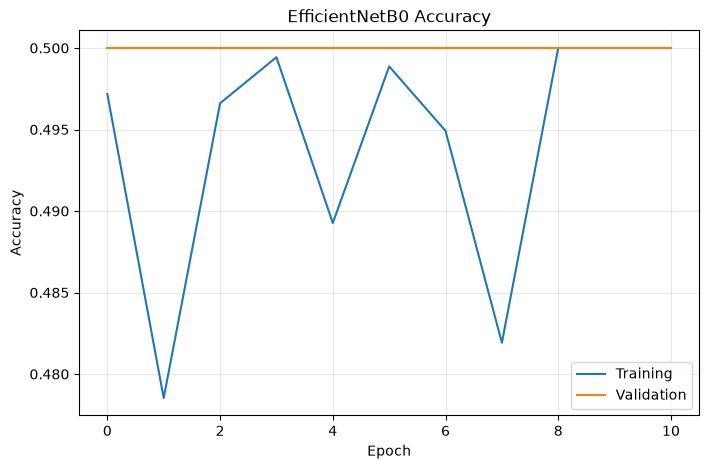

In [30]:
# Create a figure for plotting the transfer-learning model's
# training and validation accuracy
plt.figure(
    figsize=(8, 5)
)

# Plot the training accuracy for each epoch
plt.plot(
    transfer_history.history[
        "accuracy"
    ],
    label="Training"
)

# Plot the validation accuracy for each epoch
plt.plot(
    transfer_history.history[
        "val_accuracy"
    ],
    label="Validation"
)

# Label the horizontal axis
plt.xlabel("Epoch")

# Label the vertical axis
plt.ylabel("Accuracy")

# Add a title to the graph
plt.title(
    "EfficientNetB0 Accuracy"
)

# Display the legend
plt.legend()

# Add a light grid to make the graph easier to read
plt.grid(
    alpha=0.3
)

# Display the graph
plt.show()

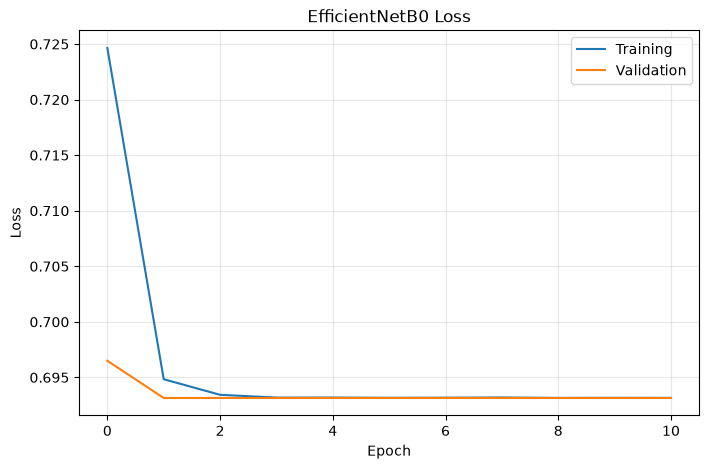

In [31]:
# Create a figure for plotting the transfer-learning model's
# training and validation loss
plt.figure(
    figsize=(8, 5)
)

# Plot the training loss for each epoch
plt.plot(
    transfer_history.history[
        "loss"
    ],
    label="Training"
)

# Plot the validation loss for each epoch
plt.plot(
    transfer_history.history[
        "val_loss"
    ],
    label="Validation"
)

# Label the horizontal axis
plt.xlabel("Epoch")

# Label the vertical axis
plt.ylabel("Loss")

# Add a title to the graph
plt.title(
    "EfficientNetB0 Loss"
)

# Display the legend
plt.legend()

# Add a light grid to make the graph easier to read
plt.grid(
    alpha=0.3
)

# Display the graph
plt.show()

In [32]:
# Evaluate the EfficientNetB0 transfer-learning model
# using the unseen test dataset
transfer_test_results = (
    transfer_model.evaluate(
        test_dataset,

        # Display evaluation progress
        verbose=1
    )
)

# Display the raw test results returned by the model
print(
    transfer_test_results
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.5065 - auc: 0.5000 - loss: 0.6931 - precision: 0.0000e+00 - recall: 0.0000e+00
[0.6931412220001221, 0.5064935088157654, 0.0, 0.0, 0.5]


In [33]:
# Use the EfficientNetB0 transfer-learning model
# to predict the probability of Parkinson's
# for every MRI image in the test dataset
transfer_probabilities = (
    transfer_model.predict(
        test_dataset
    )

    # Convert the output from shape (n, 1)
    # into a one-dimensional NumPy array
    .flatten()
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step


In [34]:
# Convert the EfficientNetB0 predicted probabilities
# into binary class predictions
transfer_predictions = (
    transfer_probabilities
    >= 0.5
).astype(int)

In [35]:
# Extract the true class labels from the test DataFrame
true_labels = (
    test_df[
        "label"
    ]

    # Convert the labels to integer values
    .astype(int)

    # Convert the pandas Series into a NumPy array
    .values
)

In [36]:
# Calculate the overall slice-level accuracy
# for the EfficientNetB0 transfer-learning model
transfer_accuracy = (
    accuracy_score(
        true_labels,
        transfer_predictions
    )
)

# Calculate slice-level precision
# This measures how many slices predicted as Parkinson's
# were actually Parkinson's
transfer_precision = (
    precision_score(
        true_labels,
        transfer_predictions,
        zero_division=0
    )
)

# Calculate slice-level recall
# This measures how many actual Parkinson's slices
# were correctly identified by the model
transfer_recall = (
    recall_score(
        true_labels,
        transfer_predictions,
        zero_division=0
    )
)

# Calculate the slice-level F1-score
# This combines precision and recall into one measure
transfer_f1 = (
    f1_score(
        true_labels,
        transfer_predictions,
        zero_division=0
    )
)

# Calculate the ROC-AUC score using predicted probabilities
# rather than the final binary class predictions
transfer_auc = (
    roc_auc_score(
        true_labels,
        transfer_probabilities
    )
)

In [37]:
# Display the EfficientNetB0 transfer-learning
# model's slice-level accuracy
print(
    f"Accuracy:  {transfer_accuracy:.4f}"
)

# Display the slice-level precision
print(
    f"Precision: {transfer_precision:.4f}"
)

# Display the slice-level recall
print(
    f"Recall:    {transfer_recall:.4f}"
)

# Display the slice-level F1-score
print(
    f"F1:        {transfer_f1:.4f}"
)

# Display the slice-level ROC-AUC score
print(
    f"ROC-AUC:   {transfer_auc:.4f}"
)

Accuracy:  0.5065
Precision: 0.0000
Recall:    0.0000
F1:        0.0000
ROC-AUC:   0.4974


In [39]:
# Generate the classification report without
# producing warnings for classes with no predictions
print(
    classification_report(
        true_labels,
        transfer_predictions,
        target_names=[
            "Control",
            "Parkinson's"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Control       0.51      1.00      0.67       195
 Parkinson's       0.00      0.00      0.00       190

    accuracy                           0.51       385
   macro avg       0.25      0.50      0.34       385
weighted avg       0.26      0.51      0.34       385



In [40]:
# Create a confusion matrix for the
# EfficientNetB0 transfer-learning model
transfer_cm = (
    confusion_matrix(
        true_labels,
        transfer_predictions
    )
)

# Display the confusion matrix
print(
    transfer_cm
)

[[195   0]
 [190   0]]


In [41]:
# Extract the four values from the
# EfficientNetB0 confusion matrix
tn, fp, fn, tp = (
    transfer_cm.ravel()
)

# Calculate sensitivity (recall for Parkinson's)
# This measures how many actual Parkinson's cases
# were correctly identified by the model
transfer_sensitivity = (
    tp / (
        tp + fn
    )
)

# Calculate specificity
# This measures how many actual control cases
# were correctly identified by the model
transfer_specificity = (
    tn / (
        tn + fp
    )
)

# Display the sensitivity score
print(
    f"Sensitivity: "
    f"{transfer_sensitivity:.4f}"
)

# Display the specificity score
print(
    f"Specificity: "
    f"{transfer_specificity:.4f}"
)

Sensitivity: 0.0000
Specificity: 1.0000


In [42]:
# Create a copy of the test DataFrame
# so the original test data remains unchanged
transfer_results_df = (
    test_df.copy()
)

# Add the EfficientNetB0 predicted probability
# for each MRI slice to the copied DataFrame
transfer_results_df[
    "probability"
] = (
    transfer_probabilities
)

In [43]:
# Group the slice-level EfficientNetB0 predictions
# so that each subject has one overall prediction score
transfer_subject_predictions = (
    transfer_results_df

    # Group together all MRI slices belonging
    # to the same subject
    .groupby(
        [
            "subject_id",
            "class",
            "label"
        ]
    )

    # Calculate the mean predicted probability
    # across all slices for each subject
    .agg(
        mean_probability=(
            "probability",
            "mean"
        )
    )

    # Convert the grouped result back
    # into a normal DataFrame
    .reset_index()
)

In [44]:
# Convert each subject's mean predicted probability
# into a final binary class prediction
transfer_subject_predictions[
    "prediction"
] = (
    transfer_subject_predictions[
        "mean_probability"
    ]

    # Use 0.5 as the classification threshold
    >= 0.5
).astype(int)

In [45]:
# Calculate subject-level accuracy for the
# EfficientNetB0 transfer-learning model
transfer_subject_accuracy = (
    accuracy_score(
        # True class for each subject
        transfer_subject_predictions[
            "label"
        ],

        # Predicted class for each subject
        transfer_subject_predictions[
            "prediction"
        ]
    )
)

# Display the subject-level accuracy
print(
    f"Subject-level accuracy: "
    f"{transfer_subject_accuracy:.4f}"
)

Subject-level accuracy: 0.5065


In [46]:
# Generate and display a subject-level classification report
# for the EfficientNetB0 transfer-learning model
print(
    classification_report(
        # True class for each subject
        transfer_subject_predictions[
            "label"
        ],

        # Predicted class for each subject
        transfer_subject_predictions[
            "prediction"
        ],

        # Display readable class names
        target_names=[
            "Control",
            "Parkinson's"
        ],

        # Avoid warnings if the model predicts
        # no subjects for one of the classes
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Control       0.51      1.00      0.67        39
 Parkinson's       0.00      0.00      0.00        38

    accuracy                           0.51        77
   macro avg       0.25      0.50      0.34        77
weighted avg       0.26      0.51      0.34        77



In [47]:
# Create the file path where the trained
# EfficientNetB0 feature-extractor model will be saved
TRANSFER_MODEL_FILE = (
    MODEL_DIR
    / "efficientnet_feature_extractor.keras"
)

# Save the complete trained Keras model
# including its architecture and learned weights
transfer_model.save(
    TRANSFER_MODEL_FILE
)

# Display the location of the saved model file
print(
    TRANSFER_MODEL_FILE
)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/models/efficientnet_feature_extractor.keras


In [48]:
# Convert the EfficientNetB0 training history
# into a pandas DataFrame
transfer_history_df = (
    pd.DataFrame(
        transfer_history.history
    )
)

# Save the training history to a CSV file
# inside the results directory
transfer_history_df.to_csv(
    RESULTS_DIR
    / "efficientnet_history.csv",

    # Do not save the DataFrame index as a column
    index=False
)

In [49]:
# Create a one-row DataFrame containing the main
# evaluation results for the EfficientNetB0 model
transfer_results = pd.DataFrame([
    {
        # Name of the model being evaluated
        "model":
            "EfficientNetB0 Feature Extraction",

        # Slice-level accuracy
        "slice_accuracy":
            transfer_accuracy,

        # Slice-level precision
        "slice_precision":
            transfer_precision,

        # Slice-level recall
        "slice_recall":
            transfer_recall,

        # Slice-level F1-score
        "slice_f1":
            transfer_f1,

        # Slice-level ROC-AUC score
        "slice_auc":
            transfer_auc,

        # Subject-level accuracy
        "subject_accuracy":
            transfer_subject_accuracy,

        # Sensitivity for detecting Parkinson's
        "sensitivity":
            transfer_sensitivity,

        # Specificity for correctly identifying controls
        "specificity":
            transfer_specificity
    }
])

# Display the results table
transfer_results

,model,slice_accuracy,slice_precision,slice_recall,slice_f1,slice_auc,subject_accuracy,sensitivity,specificity
0,EfficientNetB0 Feature Extraction,0.506494,0.0,0.0,0.0,0.497368,0.506494,0.0,1.0


In [50]:
# Save the EfficientNetB0 evaluation results
# to a CSV file inside the results directory
transfer_results.to_csv(
    RESULTS_DIR
    / "efficientnet_results.csv",

    # Do not save the DataFrame index as a column
    index=False
)

In [51]:
# Freeze all layers in the pretrained EfficientNetB0 base model
# so their ImageNet-trained weights are not changed during training
base_model.trainable = False

In [52]:
# Unfreeze the pretrained EfficientNetB0 base model
# so some of its layers can be fine-tuned on the MRI dataset
base_model.trainable = True

In [53]:
# Display the total number of layers
# contained inside the EfficientNetB0 base model
print(
    len(base_model.layers)
)

238


In [54]:
# Calculate the layer index where fine-tuning should begin
# by selecting the final 30 layers of EfficientNetB0
fine_tune_at = (
    len(base_model.layers)
    - 30
)

In [55]:
# Freeze all EfficientNetB0 layers that come
# before the selected fine-tuning point
for layer in (
    base_model.layers[
        :fine_tune_at
    ]
):
    layer.trainable = False

In [56]:
# Count how many EfficientNetB0 layers are currently
# set to be trainable during fine-tuning
trainable_count = sum(
    1
    for layer in base_model.layers
    if layer.trainable
)

# Display the number of trainable EfficientNetB0 layers
print(
    "Trainable EfficientNet layers:",
    trainable_count
)

Trainable EfficientNet layers: 30


In [57]:
# Recompile the transfer-learning model before fine-tuning
# so the newly unfrozen EfficientNetB0 layers can be updated
transfer_model.compile(

    # Use Adam with a much smaller learning rate
    # to avoid making large changes to the pretrained weights
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    # Binary cross-entropy is appropriate because
    # this is a two-class classification problem
    loss="binary_crossentropy",

    # Track the main evaluation metrics during fine-tuning
    metrics=[
        "accuracy",

        # Precision for the positive class
        # (Parkinson's)
        tf.keras.metrics.Precision(
            name="precision"
        ),

        # Recall for the positive class
        # (Parkinson's)
        tf.keras.metrics.Recall(
            name="recall"
        ),

        # Area under the ROC curve
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)


In [58]:
# Set the maximum number of additional epochs
# to use during the fine-tuning stage
FINE_TUNE_EPOCHS = 20

In [59]:
# Continue training the transfer-learning model
# using the partially unfrozen EfficientNetB0 layers
fine_tune_history = (
    transfer_model.fit(
        train_dataset,

        # Evaluate the model on the validation set
        # after each fine-tuning epoch
        validation_data=(
            val_dataset
        ),

        # Maximum number of fine-tuning epochs
        epochs=FINE_TUNE_EPOCHS,

        # Use the same callbacks to stop training early
        # and reduce the learning rate if validation loss stalls
        callbacks=[
            early_stopping,
            reduce_lr
        ]
    )
)

Epoch 1/20


/Users/paulcollingwood/Documents/Source/parkinsons_ml/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


111/111 ━━━━━━━━━━━━━━━━━━━━ 22s 145ms/step - accuracy: 0.5147 - auc: 0.5180 - loss: 0.7317 - precision: 0.5144 - recall: 0.5232 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 2/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 17s 150ms/step - accuracy: 0.5119 - auc: 0.5033 - loss: 0.7219 - precision: 0.5102 - recall: 0.5910 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6936 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 3/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 17s 148ms/step - accuracy: 0.5158 - auc: 0.5124 - loss: 0.7124 - precision: 0.5143 - recall: 0.5706 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6932 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 4/20
111/111 ━━━━━━━━━━━━━━━━━━━━ 16s 140ms/step - accuracy: 0.5141 - auc: 0.5135 - loss: 0.7034 - precision: 0.5142 - recall: 0.5130 - val_accuracy: 0.5000 - val

In [61]:
# Use the fine-tuned EfficientNetB0 model
# to predict Parkinson's probabilities
# for all MRI slices in the test dataset
fine_tune_probabilities = (
    transfer_model.predict(
        test_dataset
    )

    # Convert the predictions from shape (n, 1)
    # into a one-dimensional NumPy array
    .flatten()
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step


In [62]:
# Convert the fine-tuned EfficientNetB0
# predicted probabilities into binary class predictions
fine_tune_predictions = (
    fine_tune_probabilities

    # Use 0.5 as the classification threshold
    >= 0.5
).astype(int)

In [63]:
# Calculate slice-level accuracy for the
# fine-tuned EfficientNetB0 model
fine_accuracy = (
    accuracy_score(
        true_labels,
        fine_tune_predictions
    )
)

# Calculate slice-level precision
# for the Parkinson's class
fine_precision = (
    precision_score(
        true_labels,
        fine_tune_predictions,
        zero_division=0
    )
)

# Calculate slice-level recall
# for the Parkinson's class
fine_recall = (
    recall_score(
        true_labels,
        fine_tune_predictions,
        zero_division=0
    )
)

# Calculate the slice-level F1-score
# by combining precision and recall
fine_f1 = (
    f1_score(
        true_labels,
        fine_tune_predictions,
        zero_division=0
    )
)

# Calculate the ROC-AUC score using
# the predicted probabilities
fine_auc = (
    roc_auc_score(
        true_labels,
        fine_tune_probabilities
    )
)

In [64]:
# Display the slice-level accuracy for the
# fine-tuned EfficientNetB0 model
print(
    f"Accuracy:  {fine_accuracy:.4f}"
)

# Display the slice-level precision
print(
    f"Precision: {fine_precision:.4f}"
)

# Display the slice-level recall
print(
    f"Recall:    {fine_recall:.4f}"
)

# Display the slice-level F1-score
print(
    f"F1:        {fine_f1:.4f}"
)

# Display the slice-level ROC-AUC score
print(
    f"ROC-AUC:   {fine_auc:.4f}"
)

Accuracy:  0.5065
Precision: 0.0000
Recall:    0.0000
F1:        0.0000
ROC-AUC:   0.8344


In [65]:
# Create a copy of the test DataFrame
# so the original test data remains unchanged
fine_results_df = (
    test_df.copy()
)

# Add the fine-tuned EfficientNetB0
# predicted probability for each MRI slice
fine_results_df[
    "probability"
] = (
    fine_tune_probabilities
)

In [66]:
# Group the fine-tuned EfficientNetB0 slice-level
# predictions so that each subject has one overall score
fine_subject_predictions = (
    fine_results_df

    # Group all MRI slices belonging to the same subject
    .groupby(
        [
            "subject_id",
            "class",
            "label"
        ]
    )

    # Calculate the mean predicted probability
    # across all slices for each subject
    .agg(
        mean_probability=(
            "probability",
            "mean"
        )
    )

    # Convert the grouped result back
    # into a normal DataFrame
    .reset_index()
)

In [67]:
# Convert each subject's mean predicted probability
# into a final binary class prediction
fine_subject_predictions[
    "prediction"
] = (
    fine_subject_predictions[
        "mean_probability"
    ]

    # Use 0.5 as the classification threshold
    >= 0.5
).astype(int)

In [68]:
# Calculate subject-level accuracy for the
# fine-tuned EfficientNetB0 model
fine_subject_accuracy = (
    accuracy_score(
        # True class for each subject
        fine_subject_predictions[
            "label"
        ],

        # Predicted class for each subject
        fine_subject_predictions[
            "prediction"
        ]
    )
)

# Display the subject-level accuracy
print(
    f"Subject-level accuracy: "
    f"{fine_subject_accuracy:.4f}"
)

Subject-level accuracy: 0.5065


In [69]:
# Save the fine-tuned EfficientNetB0 model
# to the models directory
transfer_model.save(
    MODEL_DIR
    / "efficientnet_finetuned.keras"
)

In [70]:
# Load the saved results for the improved CNN model
# from the results directory
improved_results = pd.read_csv(
    RESULTS_DIR
    / "improved_cnn_results.csv"
)

In [71]:
# Create a dictionary containing the saved evaluation
# metrics for the frozen EfficientNetB0 model
efficientnet_frozen_row = {
    # Name used to identify the model
    "model":
        "EfficientNetB0 Frozen",

    # Slice-level accuracy
    "slice_accuracy":
        transfer_accuracy,

    # Slice-level precision
    "slice_precision":
        transfer_precision,

    # Slice-level recall
    "slice_recall":
        transfer_recall,

    # Slice-level F1-score
    "slice_f1":
        transfer_f1,

    # Slice-level ROC-AUC score
    "slice_auc":
        transfer_auc,

    # Subject-level accuracy
    "subject_accuracy":
        transfer_subject_accuracy,

    # Sensitivity for detecting Parkinson's
    "sensitivity":
        transfer_sensitivity,

    # Specificity for correctly identifying controls
    "specificity":
        transfer_specificity
}

In [72]:
# Create the confusion matrix for the
# fine-tuned EfficientNetB0 model
fine_cm = confusion_matrix(
    true_labels,
    fine_tune_predictions
)

# Extract the four confusion-matrix values
# TN = true negatives
# FP = false positives
# FN = false negatives
# TP = true positives
tn, fp, fn, tp = (
    fine_cm.ravel()
)

# Calculate sensitivity
# This measures how many actual Parkinson's cases
# were correctly identified
fine_sensitivity = (
    tp / (
        tp + fn
    )
)

# Calculate specificity
# This measures how many actual control cases
# were correctly identified
fine_specificity = (
    tn / (
        tn + fp
    )
)

In [73]:
# Create a dictionary containing the evaluation
# metrics for the fine-tuned EfficientNetB0 model
efficientnet_fine_row = {
    # Name used to identify the model
    "model":
        "EfficientNetB0 Fine-tuned",

    # Slice-level accuracy
    "slice_accuracy":
        fine_accuracy,

    # Slice-level precision
    "slice_precision":
        fine_precision,

    # Slice-level recall
    "slice_recall":
        fine_recall,

    # Slice-level F1-score
    "slice_f1":
        fine_f1,

    # Slice-level ROC-AUC score
    "slice_auc":
        fine_auc,

    # Subject-level accuracy
    "subject_accuracy":
        fine_subject_accuracy,

    # Sensitivity for detecting Parkinson's
    "sensitivity":
        fine_sensitivity,

    # Specificity for correctly identifying controls
    "specificity":
        fine_specificity
}

In [74]:
# Combine the improved CNN results with the
# frozen and fine-tuned EfficientNetB0 results
final_comparison = pd.concat(
    [
        # Existing improved CNN results
        improved_results,

        # Convert the two EfficientNet result
        # dictionaries into a DataFrame
        pd.DataFrame([
            efficientnet_frozen_row,
            efficientnet_fine_row
        ])
    ],

    # Create a new continuous row index
    ignore_index=True
)

# Display the final comparison table
final_comparison

,model,slice_accuracy,slice_precision,slice_recall,slice_f1,slice_auc,subject_accuracy,sensitivity,specificity
0,Improved CNN,0.823377,0.805,0.847368,0.825641,0.915735,0.896104,0.847368,0.8
1,EfficientNetB0 Frozen,0.506494,0.000,0.000000,0.000000,0.497368,0.506494,0.000000,1.0
2,EfficientNetB0 Fine-tuned,0.506494,0.000,0.000000,0.000000,0.834386,0.506494,0.000000,1.0


In [75]:
# Save the final model comparison table
# to a CSV file inside the results directory
final_comparison.to_csv(
    RESULTS_DIR
    / "model_comparison_stage6.csv",

    # Do not save the DataFrame index as an extra column
    index=False
)